In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [3]:
df = pd.read_csv("bank-additional/bank-additional-full.csv", sep =";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df.shape

(41188, 21)

In [5]:
df.size

864948

In [6]:
df.dtypes

age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

In [7]:
df = df.astype(
    {"age": "int16", "duration": "int16", "campaign": "int16", "pdays": "int16", "previous": "int16"}
)

In [8]:
df = df.astype(
    { "emp.var.rate": "float32", "cons.price.idx": "float32", "cons.conf.idx": "float32", 
     "euribor3m": "float32", "nr.employed": "float32","job": "category", "marital": "category",
     "education": "category", "default": "category", "housing": "category", "loan": "category",
     "contact": "category", "month": "category", "day_of_week": "category", "poutcome": "category", 
     "y": "category"})

In [9]:
df.dtypes

age                  int16
job               category
marital           category
education         category
default           category
housing           category
loan              category
contact           category
month             category
day_of_week       category
duration             int16
campaign             int16
pdays                int16
previous             int16
poutcome          category
emp.var.rate       float32
cons.price.idx     float32
cons.conf.idx      float32
euribor3m          float32
nr.employed        float32
y                 category
dtype: object

In [10]:
df.size

864948

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             41188 non-null  int16   
 1   job             41188 non-null  category
 2   marital         41188 non-null  category
 3   education       41188 non-null  category
 4   default         41188 non-null  category
 5   housing         41188 non-null  category
 6   loan            41188 non-null  category
 7   contact         41188 non-null  category
 8   month           41188 non-null  category
 9   day_of_week     41188 non-null  category
 10  duration        41188 non-null  int16   
 11  campaign        41188 non-null  int16   
 12  pdays           41188 non-null  int16   
 13  previous        41188 non-null  int16   
 14  poutcome        41188 non-null  category
 15  emp.var.rate    41188 non-null  float32 
 16  cons.price.idx  41188 non-null  float32 
 17  cons.conf.idx   41188 n

In [12]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081885,93.575668,-40.502605,3.621291,5167.036133
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578841,4.628198,1.734447,72.251511
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.200996,-50.799999,0.634000,4963.600098
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.074997,-42.700001,1.344000,5099.100098
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749001,-41.799999,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994003,-36.400002,4.961000,5228.100098
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.766998,-26.900000,5.045000,5228.100098


In [13]:
df[df["duration"] > 3500].shape

(6, 21)

In [14]:
df.head(2)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994003,-36.400002,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994003,-36.400002,4.857,5191.0,no


<Axes: >

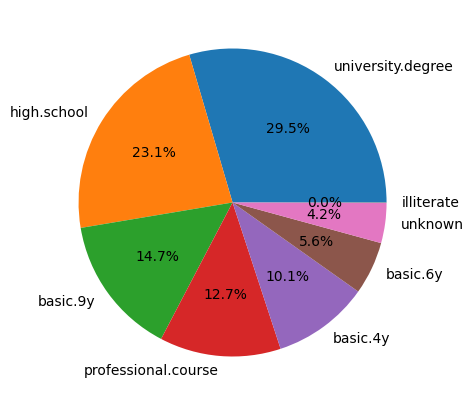

In [45]:
df["education"].value_counts().plot(kind = "pie", autopct = "%1.1f%%", figsize = (5, 5))

<Axes: >

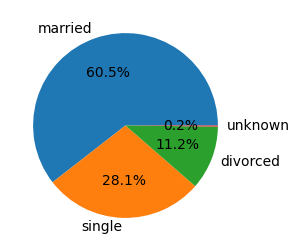

In [16]:
df["marital"].value_counts().plot(kind = "pie", autopct = "%1.1f%%",  figsize = (3,3))

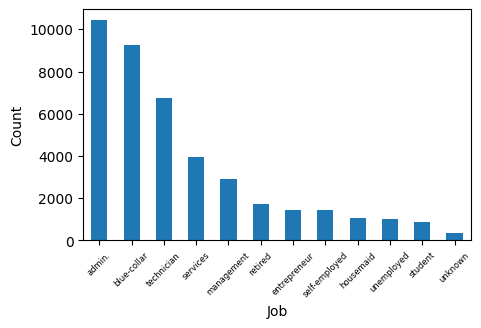

In [ ]:
plt.figure(figsize = (5,3))
df["job"].value_counts().plot(kind = "bar" )
plt.xlabel("Job")
plt.ylabel("Count")
plt.xticks(rotation = 45, size = 6)
plt.show()

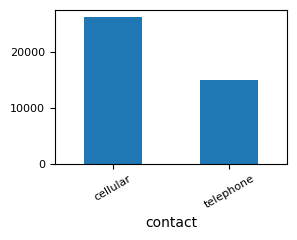

In [18]:
df["contact"].value_counts().plot(kind = "bar", figsize = (3,2))
plt.xticks(rotation = 30, size = 8)
plt.yticks(size = 8)
plt.show()

<Axes: ylabel='month'>

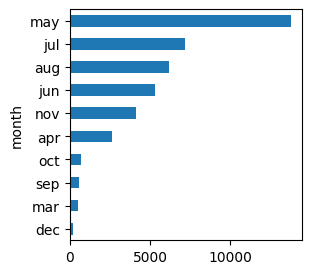

In [50]:
df["month"].value_counts().sort_values().plot(kind = "barh", figsize = (3,3))

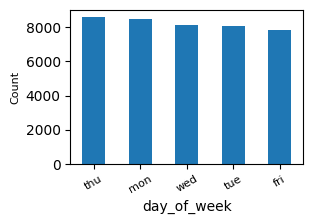

In [20]:
df["day_of_week"].value_counts().plot(kind = "bar", figsize = (3,2))
plt.xticks(rotation = 30, size = 8)
plt.ylabel("Count", size = 8)
plt.show()

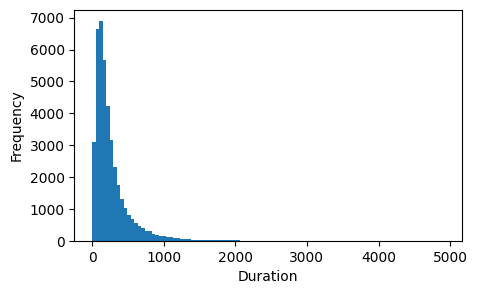

In [21]:
df["duration"].plot(kind = "hist", bins = 100, figsize = (5,3))
plt.xlabel("Duration")
plt.show()

In [22]:
emp = df.groupby("nr.employed")["y"].value_counts().reset_index()
emp.sample(5)


,nr.employed,y,count
17,5191.000000,yes,240
0,4963.600098,no,334
10,5076.200195,no,1069
7,5017.500000,yes,454
13,5099.100098,yes,1092


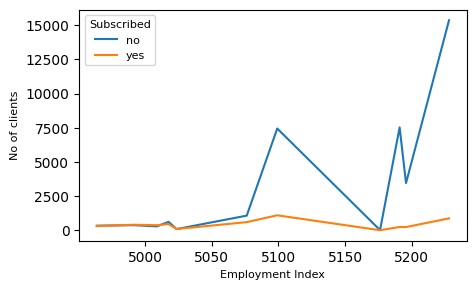

In [23]:
plt.figure(figsize = (5,3))
sns.lineplot(x = "nr.employed", y = "count", hue = "y", data = emp)
plt.ylabel("No of clients", size = 8)
plt.xlabel("Employment Index", size = 8)
plt.legend(title = "Subscribed", title_fontsize = 8, fontsize = 8)
plt.show()

In [ ]:
hl_subs = df[(df["housing"] == "yes") & (df["loan"] == "yes")]["y"].value_counts(normalize = True).mul(100).loc["yes"]
no_hl_subs = df[(df["housing"] == "no") & (df["loan"] == "no")]["y"].value_counts(normalize = True).mul(100).loc["yes"]
print(f"percentage of subscribers with housing and loan: {hl_subs:.2f}%")
print(f"percentage of subscribers with no housing and no loan: {no_hl_subs:.2f}%")

percentage of subscribers with housing and loan: 11.08%
percentage of subscribers with no housing and no loan: 10.91%


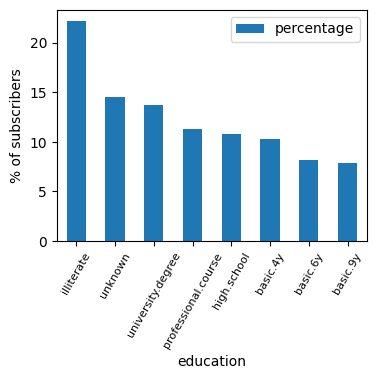

In [90]:
subs_edu = df.groupby("education")["y"].value_counts(normalize = True).mul(100).reset_index()
subscribed_wrt_edu = subs_edu[subs_edu["y"] == "yes"].sort_values("proportion", ascending = False).reset_index(drop = True)
subscribed_wrt_edu.plot(x = "education", y = "proportion", kind = "bar", figsize = (4, 3))
plt.ylabel("% of subscribers")
plt.xticks(rotation = 60, size = 8)
plt.legend(["percentage"])
plt.show()

In [102]:
A =  df[df["duration"] > df["duration"].mean()]["y"].value_counts()
B =  df[df["duration"] < df["duration"].mean()]["y"].value_counts()
print(f"Percentage of subscribers who were contacted for less than the average duration: {B['yes']/B.sum()*100:.2f}%")
print(f"Percentage of subscribers who were contacted for more than the average duration: {A['yes']/A.sum()*100:.2f}%")

Percentage of subscribers who were contacted for less than the average duration: 4.36%
Percentage of subscribers who were contacted for more than the average duration: 25.18%
